In [1]:
import glob
import re
import os

import numpy as np
from pathlib import Path

from pymor.basic import *
from pymor.core.pickle import load

from RBInvParam.problems.elasticity.build import build_InstationaryModelIP

set_log_levels({
    'pymor' : 'WARN'
})


In [4]:
import matplotlib as mpl
import matplotlib.pyplot as plt

# plt.rcParams.update({
#     "text.usetex": True,
#     "font.family": "cm",
#     "font.size": 10,
#     'text.latex.preamble': r'\usepackage{amsfonts} \usepackage{accents} \usepackage{mathrsfs} \usepackage{bm}',
#     'figure.dpi': 200
# })

In [49]:
WORK_DIR = Path('/home/dealii/workdir/examples/elasticity')
#WORK_DIR = Path('/home/benedikt/Dokumente/parabolische_inverse_probleme/examples/elasticity')
#WORK_DIR = Path('/home/benedikt/Dokumente/parabolische_inverse_probleme/experiments')

#SAVE_PATH = Path('/home/benedikt/Dokumente/Paper/parabolische_inverse_probleme/figures/experiments')

data_dir_path = WORK_DIR / 'dumps'

#FOM_data_path = data_dir_path / '20251024_101601_TR_IRGNM'
FOM_data_path = None
TR_data_path = data_dir_path / '20251112_170446_TR_IRGNM/'
#TR_data_path = None

setup_path = TR_data_path / 'setup.pkl'
optimizer_parameter_path = TR_data_path / 'optimizer_parameter.pkl'


with open(setup_path, 'rb') as file:
    setup = load(file)

with open(optimizer_parameter_path, 'rb') as file:
    optimizer_parameter = load(file)

# if not 'FOM' in locals():
#     FOM = build_InstationaryModelIP(setup=setup)

    

data = {}

if FOM_data_path:
    with open(FOM_data_path / 'FOM_IRGNM_4.pkl', 'rb') as file:
        FOM_data = load(file)
    data['FOM'] = FOM_data

if TR_data_path:
    with open(TR_data_path / 'TR_IRGNM_7.pkl', 'rb') as file:
        TR_data = load(file)
    data['TR'] = TR_data
    


In [30]:
data['TR']['dim_V_r']

[67, 134, 201]

In [34]:
for i in range(len(data['TR']['dim_V_r']) - 1):
    print(data['TR']['dim_V_r'][i+1]-data['TR']['dim_V_r'][i])

71
113


In [36]:
data['TR']['rel_est_error_J_r'] 

[0.0006801648085307887, 0.009368366750759121, 0.01917268737670677]

In [16]:
data['TR']['abs_est_error_J_r']

[1.209688935658086e-11,
 1.209688935658086e-11,
 2.7636913986903233e-11,
 2.2695281256704484e-11,
 3.2050213026454524e-11,
 5.040385253679847e-11]

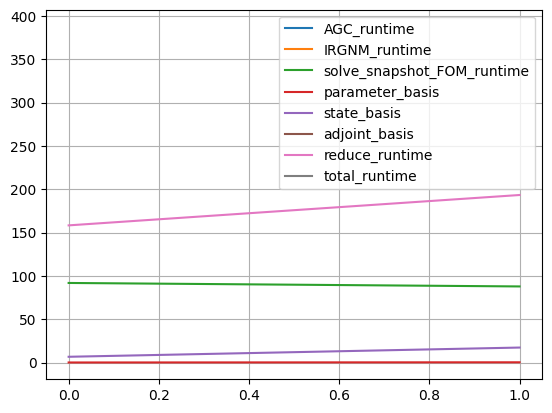

In [33]:
for key, d in data['TR']['outer_loop_runtime'].items():    
    if isinstance(d, dict):
        for key_, d_ in d.items():
            plt.plot(np.array(d_), label=key_)
    else:
        plt.plot(np.array(d), label=key)
    
plt.grid()
plt.legend()



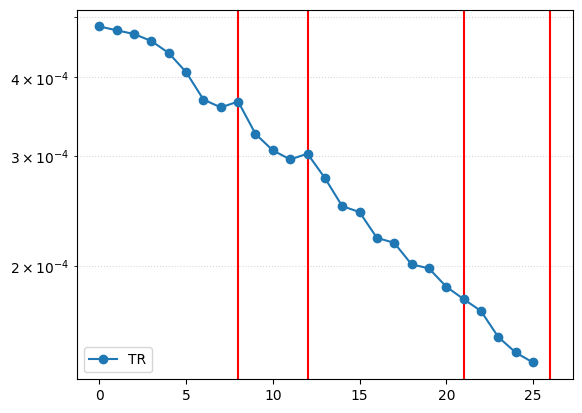

In [51]:
#plt.plot(data['FOM']['J'], marker='o', label='FOM')

TR_Js = []
inner_loop_statistics = data['TR']['inner_loop_statistics']
idxes = []

for inner_loop_statistic in inner_loop_statistics:
    try:
        TR_Js += inner_loop_statistic['J']
        idxes.append(len(inner_loop_statistic['J']))
        plt.axvline(len(TR_Js), color='r')
    except:
        pass

TR_Js = np.sqrt(2 * np.array(TR_Js))

plt.plot(TR_Js, marker='o', label='TR')
plt.yscale('log')
plt.legend()

plt.grid(True, which='major', linestyle='-', alpha=0.7)
plt.grid(True, which='minor', linestyle=':', alpha=0.5)
plt.grid()

In [51]:
Js = np.array(data['TR']['J'])
Js

array([1.32052315e-08, 8.48995663e-09, 2.65301314e-09, 2.23978568e-09,
       2.41820671e-09, 2.06149811e-09])

In [52]:
J_rs = np.array(data['TR']['J_r'])
J_rs

array([1.32142194e-08, 8.69499837e-09, 2.58135836e-09, 2.66059834e-09,
       2.42923732e-09, 2.41971465e-09])

In [44]:
np.abs(Js - J_rs) / np.abs(J_rs) *100

array([0.13059071, 0.9132991 , 1.1593109 ])

In [56]:
# inner_loop_statistics = data['TR']['inner_loop_statistics']
# for inner_loop_statistic in inner_loop_statistics:
#     print(inner_loop_statistic['J'])

In [41]:
plt.imshow(data['FOM']['q'][-1].to_numpy().reshape((31,31)))
plt.colorbar() 

KeyError: 'FOM'

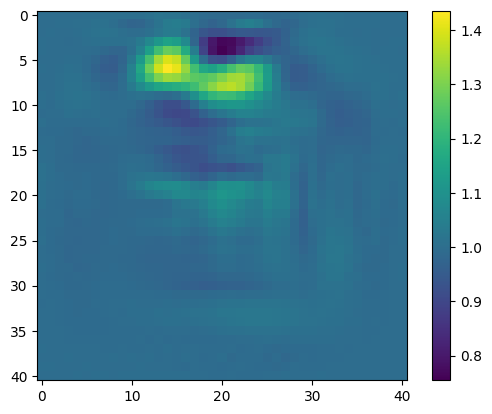

In [52]:
plt.imshow(data['TR']['q'][-1].to_numpy().reshape((41,41)))
#plt.imshow(data['TR']['q'][-1].to_numpy().reshape((9,9)))
plt.colorbar() 

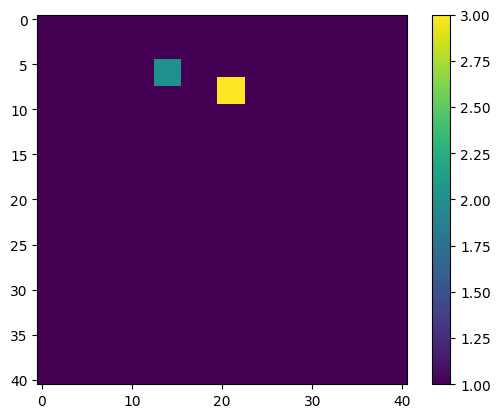

In [43]:
plt.imshow(setup['q_exact'].reshape((41,41)))
#plt.imshow(setup['q_exact'].reshape((9,9)))

plt.colorbar() 

In [40]:
data['TR']['rel_est_error_nabla_J_r']

[nan, nan, nan, nan]

In [11]:
data['TR']['J']

[6.706834566982598e-09, 5.423277401771439e-09]

In [12]:
A(d(t))data['TR']['total_runtime']

[170.27885965799942]

In [18]:
TR_time = np.array([0])
TR_time = np.append(TR_time, data['TR']['total_runtime'])

In [19]:
TR_time

array([  0.        ,  76.13332769, 130.14739309, 184.44696403,
       259.38747067, 367.46536092, 464.30858356, 552.05394785])

In [17]:
data['TR']['J']

[1.7139581906348804e-06,
 1.7139580838617333e-06,
 1.6391430704694137e-06,
 1.6158697953465365e-06,
 1.5753893604999023e-06,
 1.5588901878503426e-06]

ValueError: x and y must have same first dimension, but have shapes (8,) and (6,)

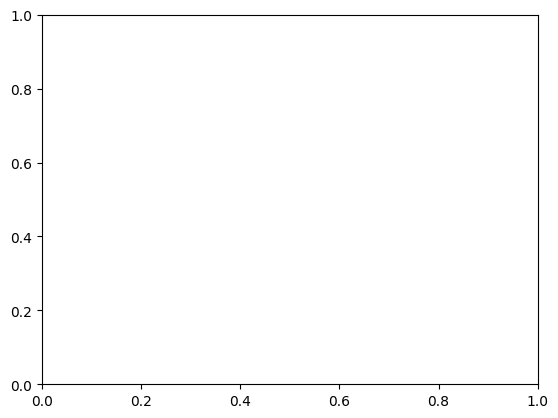

In [15]:
#FOM_time = np.array([0])
#FOM_time = np.append(FOM_time, data['FOM']['total_runtime'][:-1])

TR_time = np.array([0])
TR_time = np.append(TR_time, data['TR']['total_runtime'])

#plt.plot(FOM_time, data['FOM']['J'], marker='o', label='FOM')
plt.plot(TR_time, data['TR']['J'], marker='o', label='TR')
plt.legend()
plt.grid()

In [117]:
FOM_time[-1] / TR_time[-1]

5.3886416959484205

In [116]:
TR_time

array([   0.        ,  281.87537163,  842.57649428, 1522.79777066,
       2256.30833836, 2791.88258994, 3645.68812381, 4434.0970234 ,
       5180.15627514, 6117.56853522, 6235.29021574])

In [77]:
FOM_time

array([    0.        ,   381.09664286,   970.31124547,  1537.89829014,
        2182.55503368,  2572.2450079 ,  3223.15867392,  3623.40257315,
        3996.12863357,  4357.48694625,  5004.68899668,  5341.7270296 ,
        5669.82772411,  6000.11305625,  6331.38848558,  6663.14859324,
        7233.85223462,  7647.03836191,  8047.40782674,  8435.77360353,
        8796.28760347,  9166.8612351 ,  9536.40645639,  9897.64036538,
       10311.83550789, 11184.1946812 , 11653.16449573, 12117.29287373,
       12589.18117455, 12991.87351588, 13382.85625329, 13750.21707426,
       14129.39005733, 14536.78488568, 14938.84621536, 15336.55011359,
       15728.42640334, 16155.63038758, 16538.19418832, 16920.12921192,
       17327.1083017 , 17770.61664301, 18191.64580967, 18635.81705455,
       19089.07040278, 19552.02541316, 20011.83194457, 20418.25459434,
       21178.75015843, 21571.44078826, 21962.37627042, 22307.84004986,
       22637.59075572, 22955.29368266, 23273.13224171, 23618.68402695,
      